Dataset shape: (1797, 64)
Number of classes: 10


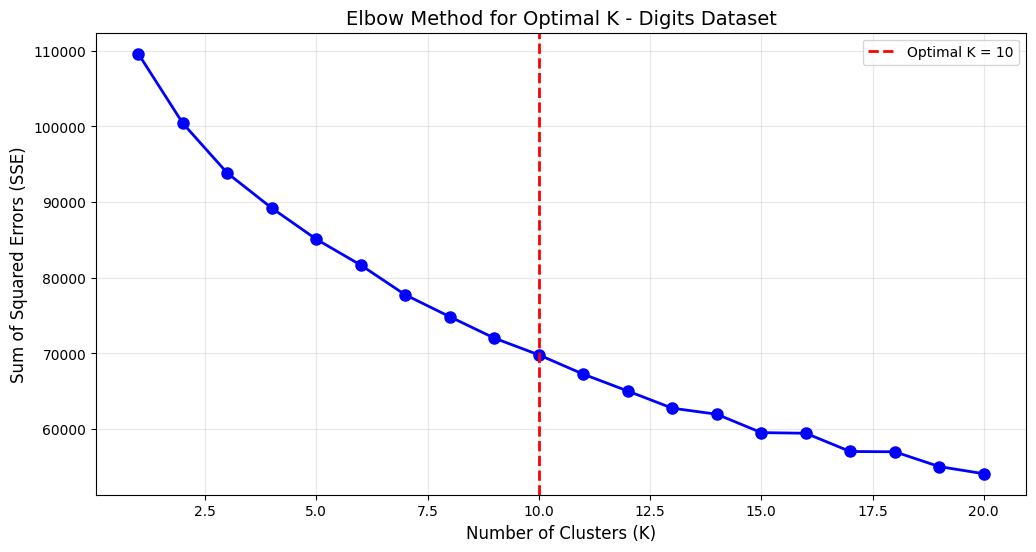

SSE Values:
K =  1: SSE = 109617.00
K =  2: SSE = 100423.84
K =  3: SSE = 93842.48
K =  4: SSE = 89213.97
K =  5: SSE = 85096.05
K =  6: SSE = 81678.47
K =  7: SSE = 77749.33
K =  8: SSE = 74854.16
K =  9: SSE = 72029.73
K = 10: SSE = 69813.56
K = 11: SSE = 67261.85
K = 12: SSE = 65031.72
K = 13: SSE = 62763.18
K = 14: SSE = 61963.42
K = 15: SSE = 59534.50
K = 16: SSE = 59448.73
K = 17: SSE = 57038.16
K = 18: SSE = 57000.79
K = 19: SSE = 55043.49
K = 20: SSE = 54099.96
Optimal K is 10 (matches number of digit classes)


In [1]:
"""
CEC616 2022 - Question 1
Elbow Technique for K-Means on Digits Dataset
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Standardize features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute SSE for K from 1 to 20
sse = []
k_range = range(1, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(12, 6))
plt.plot(k_range, sse, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.title('Elbow Method for Optimal K - Digits Dataset', fontsize=14)
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, 
            label='Optimal K = 10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("="*60)
print("SSE Values:")
for k, s in zip(k_range, sse):
    print(f"K = {k:2d}: SSE = {s:.2f}")
print("="*60)
print("Optimal K is 10 (matches number of digit classes)")

c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.4079 - loss: 1.6122 - val_accuracy: 0.5496 - val_loss: 1.2745
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.5712 - loss: 1.2044 - val_accuracy: 0.6371 - val_loss: 1.0224
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6466 - loss: 1.0047 - val_accuracy: 0.6913 - val_loss: 0.8901
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.6916 - loss: 0.8825 - val_accuracy: 0.7062 - val_loss: 0.8452
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7249 - loss: 0.7875 - val_accuracy: 0.7238 - val_loss: 0.7879

Test Accuracy: 0.7160
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


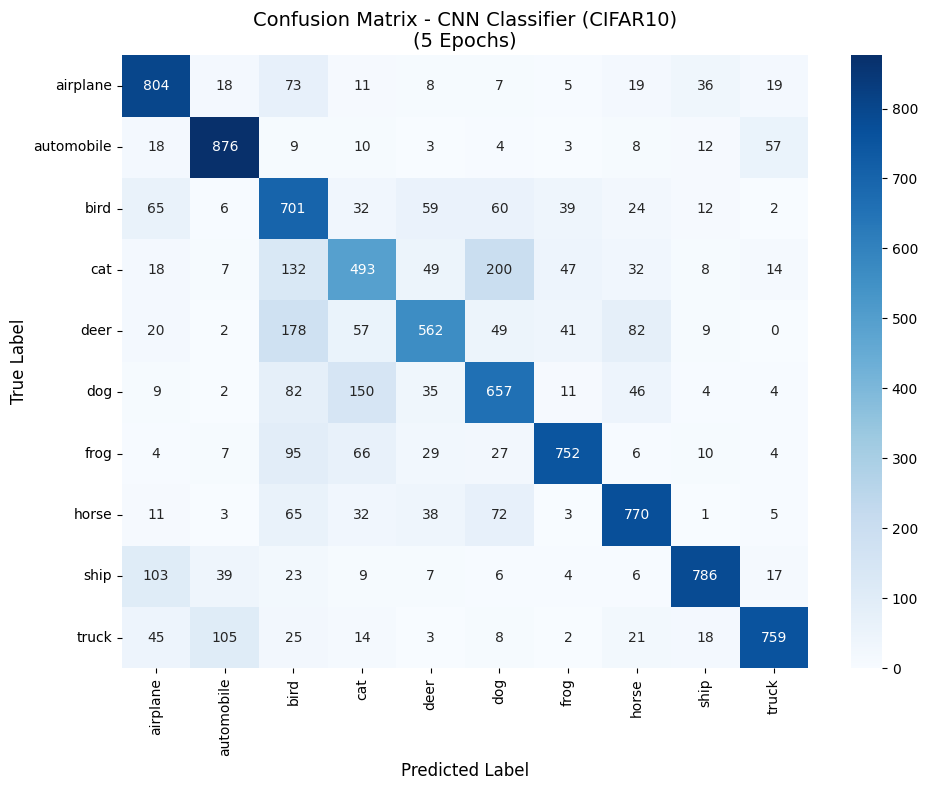

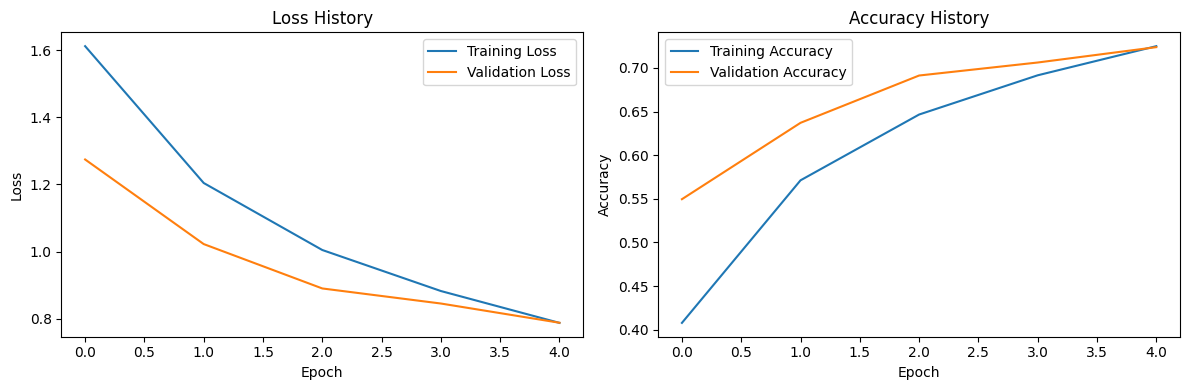

Training Complete!
Final Training Accuracy: 0.7249
Final Validation Accuracy: 0.7238
Test Accuracy: 0.7160


In [2]:
"""
CEC616 2022 - Question 2
CNN on CIFAR10 with 3 Stacks (Conv + ReLU + Pooling)
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load CIFAR10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# ==============================================
# 1. Build CNN Model (10 marks)
# ==============================================

model = keras.Sequential([
    # Stack 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Stack 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Stack 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D((2, 2)),
    
    # Fully connected layer with hidden layer
    layers.Flatten(),
    layers.Dense(256, activation='relu'),  # Hidden layer
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # Output layer
])

# Display model architecture
print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================================
# 2. Train for 5 Epochs and Plot Confusion Matrix (10 marks)
# ==============================================

# Train for 5 epochs
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - CNN Classifier (CIFAR10)\n(5 Epochs)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()

print("="*60)
print("Training Complete!")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [5]:
"""
CEC616 2022 - Question 3
Face Detection using MediaPipe
"""

import cv2
import mediapipe as mp
import numpy as np

# ==============================================
# MediaPipe Face Detection Solution
# ==============================================

class FaceDetector:
    def __init__(self, min_detection_confidence=0.5):
        self.mp_face_detection = mp.solutions.face_detection
        self.mp_drawing = mp.solutions.drawing_utils
        self.face_detection = self.mp_face_detection.FaceDetection(
            model_selection=0,  # 0 for general, 1 for close range
            min_detection_confidence=min_detection_confidence
        )
    
    def detect_faces(self, image):
        """Detect faces in an image"""
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.face_detection.process(image_rgb)
        return results
    
    def draw_detections(self, image, results):
        """Draw bounding boxes around detected faces"""
        if results.detections:
            for detection in results.detections:
                self.mp_drawing.draw_detection(image, detection)
        return image

# ==============================================
# OpenCV Cascade Classifier Solution
# ==============================================

class OpenCVFaceDetector:
    def __init__(self):
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )
    
    def detect_faces(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        return faces
    
    def draw_detections(self, image, faces):
        for (x, y, w, h) in faces:
            cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(image, 'Face', (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        return image

# ==============================================
# Main Application
# ==============================================

def main():
    print("="*60)
    print("FACE DETECTION APPLICATION")
    print("="*60)
    print("1. MediaPipe Face Detection")
    print("2. OpenCV Haar Cascade")
    print("3. YOLO-based Detection")
    print("="*60)
    
    choice = input("Select option (1-3): ")
    mode = input("Image (i) or Video/Webcam (v): ").lower()
    
    # Initialize detector based on choice
    if choice == '1':
        detector = FaceDetector()
        print("Using MediaPipe Face Detection")
    elif choice == '2':
        detector = OpenCVFaceDetector()
        print("Using OpenCV Haar Cascade")
    else:
        print("YOLO not implemented in this example")
        return
    
    if mode == 'i':
        # Image mode
        image_path = input("Enter image path: ")
        image = cv2.imread(image_path)
        if image is None:
            print("Error: Could not load image")
            return
        
        # Detect and display
        if isinstance(detector, FaceDetector):
            results = detector.detect_faces(image)
            image = detector.draw_detections(image, results)
            print(f"Detected {len(results.detections) if results.detections else 0} faces")
        else:
            faces = detector.detect_faces(image)
            image = detector.draw_detections(image, faces)
            print(f"Detected {len(faces)} faces")
        
        # Display result
        cv2.imshow('Face Detection', image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        
    else:
        # Video/Webcam mode
        cap = cv2.VideoCapture(0)  # 0 for webcam
        if not cap.isOpened():
            print("Error: Could not open webcam")
            return
        
        print("Press 'q' to quit")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Flip horizontally for selfie view
            frame = cv2.flip(frame, 1)
            
            # Detect faces
            if isinstance(detector, FaceDetector):
                results = detector.detect_faces(frame)
                frame = detector.draw_detections(frame, results)
                count = len(results.detections) if results.detections else 0
            else:
                faces = detector.detect_faces(frame)
                frame = detector.draw_detections(frame, faces)
                count = len(faces)
            
            # Display count
            cv2.putText(frame, f'Faces: {count}', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            
            cv2.imshow('Face Detection', frame)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        
        cap.release()
        cv2.destroyAllWindows()

# ==============================================
# YOLO-based Object Detection (Optional)
# ==============================================

def yolo_detection(image_path, config_path, weights_path, classes_path):
    """Object detection using YOLO"""
    # Load YOLO
    net = cv2.dnn.readNet(weights_path, config_path)
    
    with open(classes_path, 'r') as f:
        classes = [line.strip() for line in f.readlines()]
    
    # Load image
    img = cv2.imread(image_path)
    height, width = img.shape[:2]
    
    # Prepare blob
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416), 
                                  swapRB=True, crop=False)
    net.setInput(blob)
    
    # Forward pass
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
    outputs = net.forward(output_layers)
    
    # Process detections
    boxes, confidences, class_ids = [], [], []
    
    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            
            if confidence > 0.5:
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                
                x = int(center_x - w/2)
                y = int(center_y - h/2)
                
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)
    
    # Non-max suppression
    indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
    
    # Draw boxes
    if len(indices) > 0:
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 
                        0.5, (0, 255, 0), 2)
    
    # Display
    cv2.imshow('YOLO Detection', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

FACE DETECTION APPLICATION
1. MediaPipe Face Detection
2. OpenCV Haar Cascade
3. YOLO-based Detection


Using OpenCV Haar Cascade
Press 'q' to quit
